# Mimic IV Dataset – Exploratory Data Analysis (EDA)

Focus:
- Feature distributions
- Missing (null) values



## 1. Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

real_path = 'Real_Datasets/MimicIV_clean.csv'
df = pd.read_csv(real_path)

print('Dataset shape:', df.shape)
df.head()

Dataset shape: (23698, 31)


,gender,age_at_intime,heart_rate_min,heart_rate_max,heart_rate_mean,sbp_min,sbp_max,sbp_mean,dbp_min,dbp_max,...,creatinine_max,sodium_min,sodium_max,potassium_min,potassium_max,hemoglobin_min,hemoglobin_max,wbc_min,wbc_max,hospital_expire_flag
0,M,62,72.0,114.0,84.481481,77.0,153.0,112.387097,46.0,127.0,...,3.0,132.0,134.0,4.3,5.2,11.5,11.7,13.6,19.9,1
1,M,64,68.0,86.0,73.955556,86.0,154.0,103.415094,47.0,88.0,...,0.3,134.0,136.0,3.7,4.2,10.6,12.4,14.4,16.1,1
2,M,51,82.0,107.0,95.352941,112.0,181.0,147.878788,50.0,112.0,...,3.4,144.0,146.0,3.4,3.7,10.0,10.3,7.4,7.4,0
3,M,69,72.0,139.0,93.500000,52.0,184.0,107.867647,21.0,117.0,...,4.5,131.0,141.0,3.6,5.1,3.9,9.6,8.4,23.1,1
4,F,46,71.0,97.0,79.153846,96.0,123.0,115.360000,48.0,76.0,...,3.7,136.0,137.0,3.8,4.4,7.8,9.7,6.1,8.4,0


## 2. Data Types

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23698 entries, 0 to 23697
Data columns (total 31 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   gender                23698 non-null  object 
 1   age_at_intime         23698 non-null  int64  
 2   heart_rate_min        23698 non-null  float64
 3   heart_rate_max        23698 non-null  float64
 4   heart_rate_mean       23698 non-null  float64
 5   sbp_min               23698 non-null  float64
 6   sbp_max               23698 non-null  float64
 7   sbp_mean              23698 non-null  float64
 8   dbp_min               23698 non-null  float64
 9   dbp_max               23698 non-null  float64
 10  dbp_mean              23698 non-null  float64
 11  resp_rate_min         23698 non-null  float64
 12  resp_rate_max         23698 non-null  float64
 13  resp_rate_mean        23698 non-null  float64
 14  temperature_min       23698 non-null  float64
 15  temperature_max    

## 3. Missing Values

In [3]:
missing_abs = df.isna().sum().sort_values(ascending=False)
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)

missing_df = pd.DataFrame({
    'missing_count': missing_abs,
    'missing_percent': missing_pct
})

total_cells = df.shape[0] * df.shape[1]
total_missing = df.isna().sum().sum()

missing_percentage = (total_missing / total_cells) * 100
print("total missing values:", missing_percentage)

missing_df[missing_df.missing_count > 0].head(20)

total missing values: 0.0


,missing_count,missing_percent


## 4. Missing Values Plot

In [4]:
if missing_pct[missing_pct > 0].size == 0:
    print("no missing values to plot")
else:
    print(missing_pct[missing_pct > 0].size)
    plt.figure(figsize=(10,5))
    missing_pct[missing_pct > 0].plot(kind='bar')
    plt.ylabel('Missing (%)')
    plt.title('Missing Values per Column')
    plt.tight_layout()
    plt.show()

no missing values to plot


In [5]:
df_filtered = df[df.isna().sum(axis=1) <= 1]
print("Original shape:", df.shape)
print("Filtered shape:", df_filtered.shape)

print("Rows removed:", df.shape[0] - df_filtered.shape[0])

x = 30  # threshold in percent

missing_pct = df_filtered.isna().mean() * 100
df_filtered2 = df_filtered.loc[:, missing_pct <= x]
#df_filtered2 = df_filtered.drop(df_filtered.columns[[0]], axis=1)

removed = set(df_filtered.columns) - set(df_filtered2.columns)
print("Dropped columns:", removed)

print("Filtered2 shape:", df_filtered2.shape)

#df_filtered2.to_csv('Real_Datasets/MimicIV_clean.csv',index=False)

Original shape: (23698, 31)
Filtered shape: (23698, 31)
Rows removed: 0
Dropped columns: set()
Filtered2 shape: (23698, 31)


## 5. Numeric Distributions

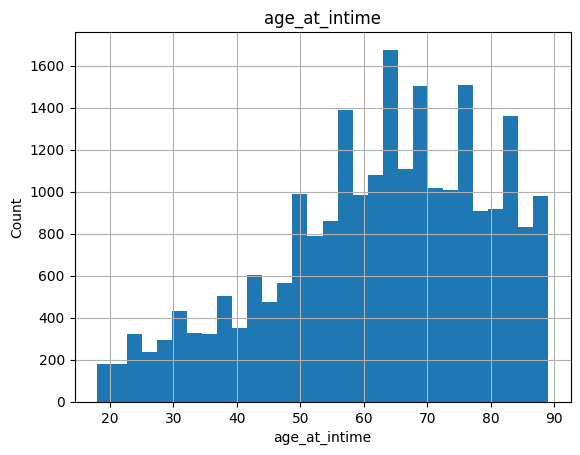

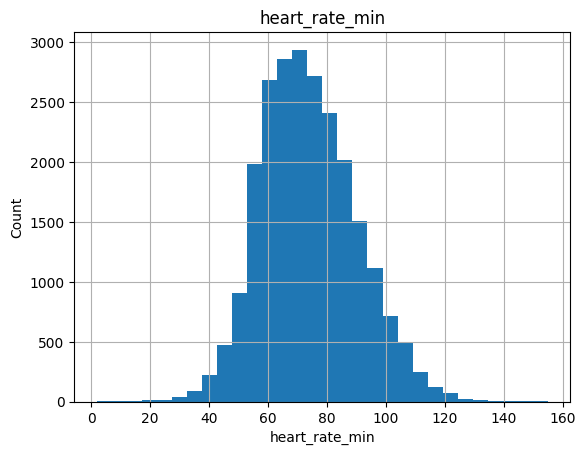

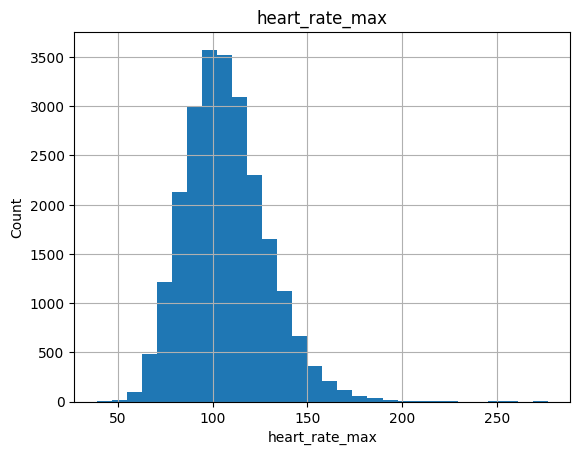

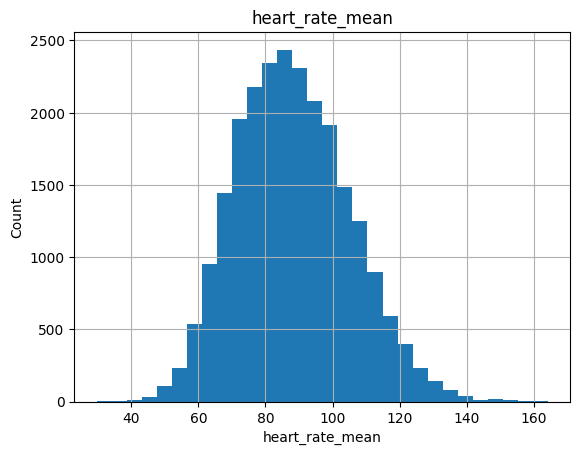

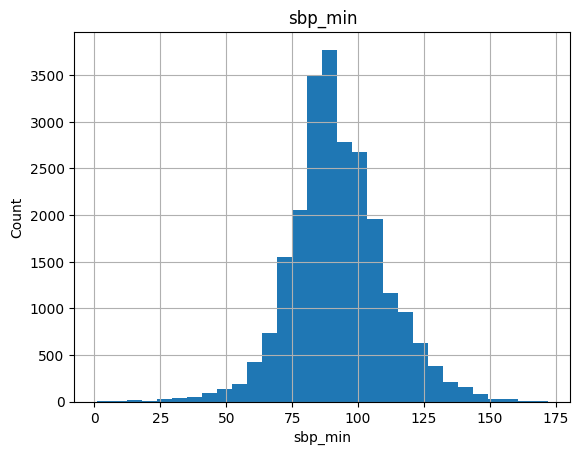

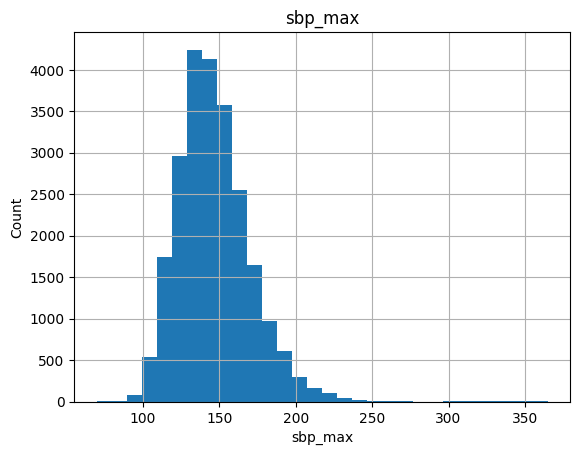

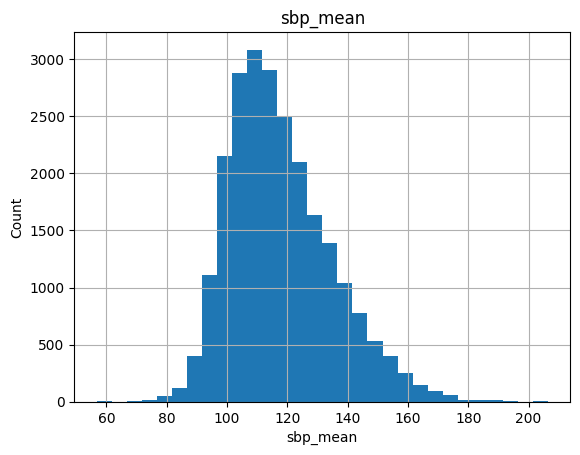

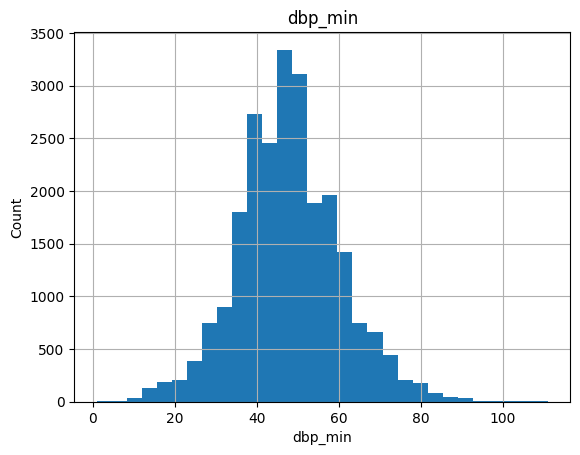

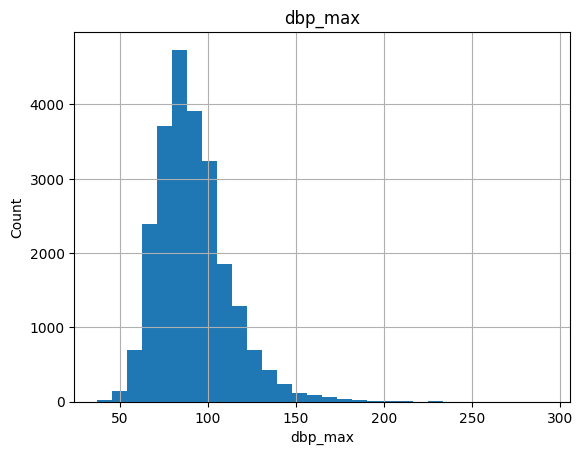

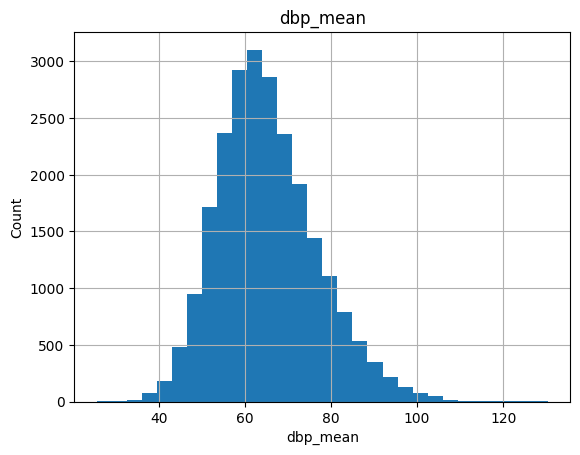

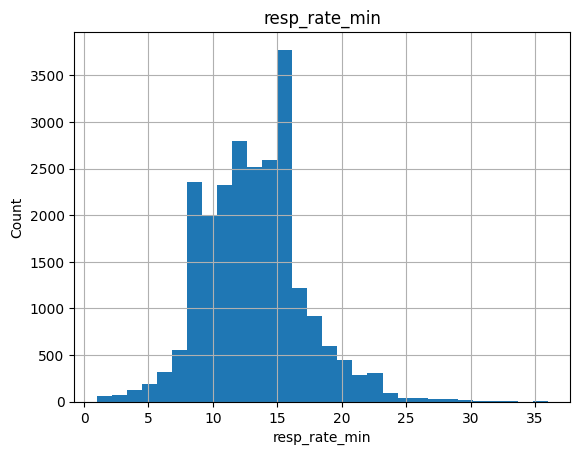

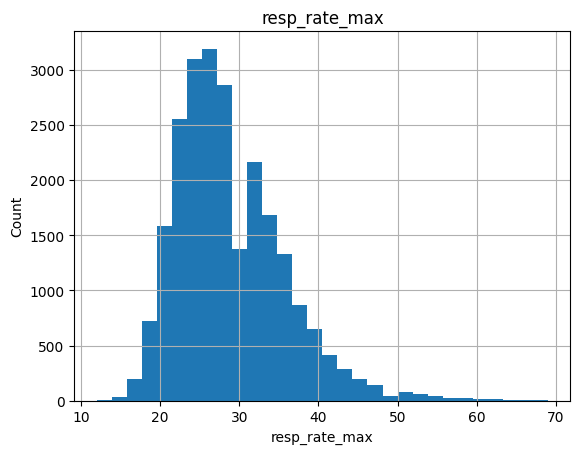

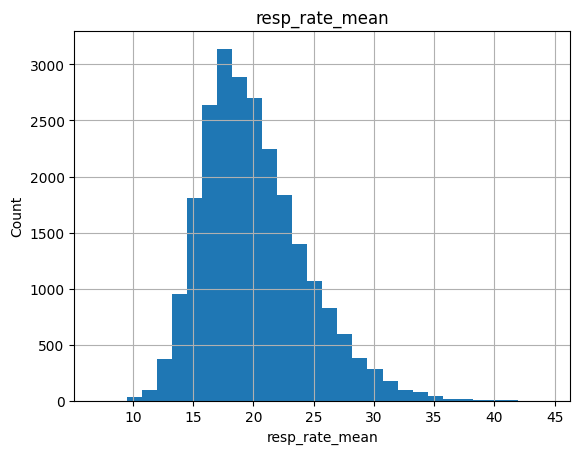

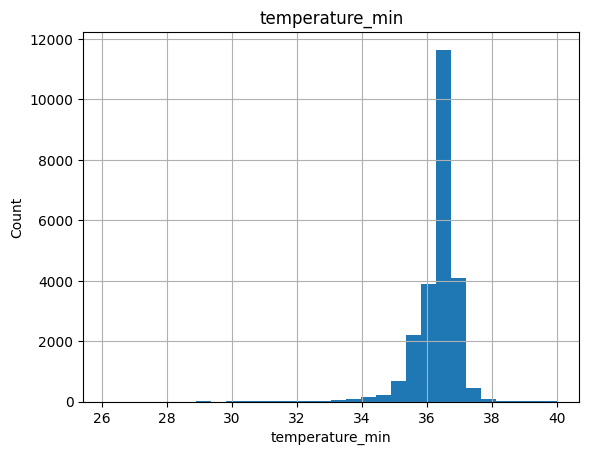

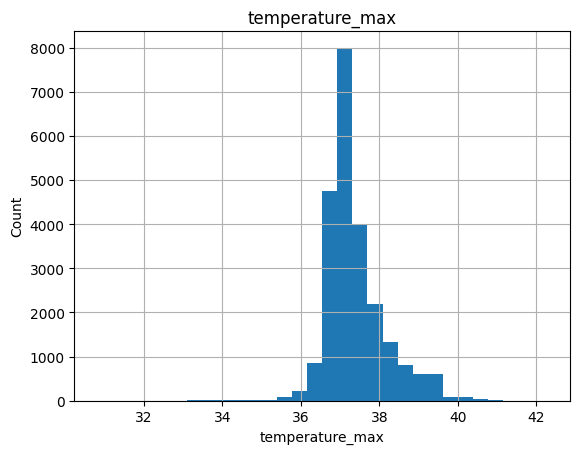

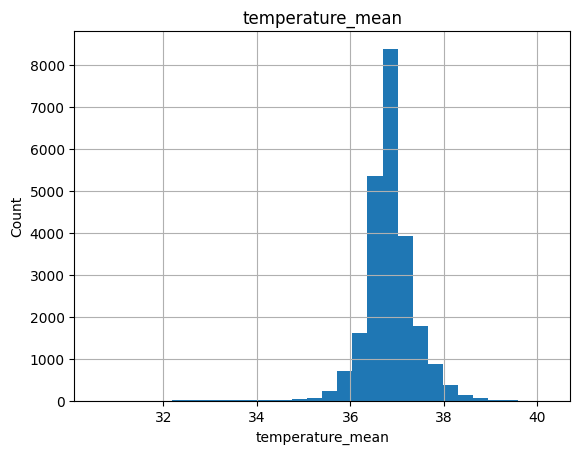

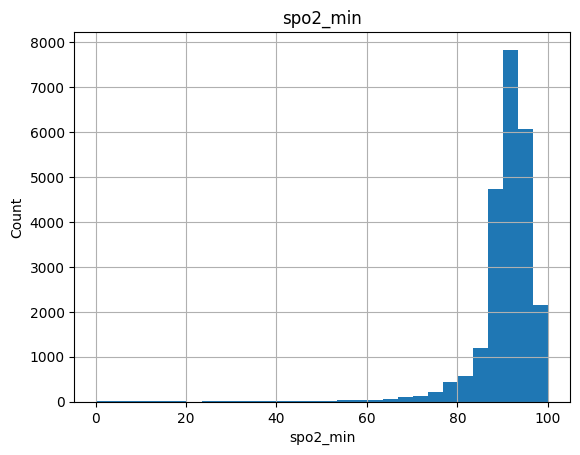

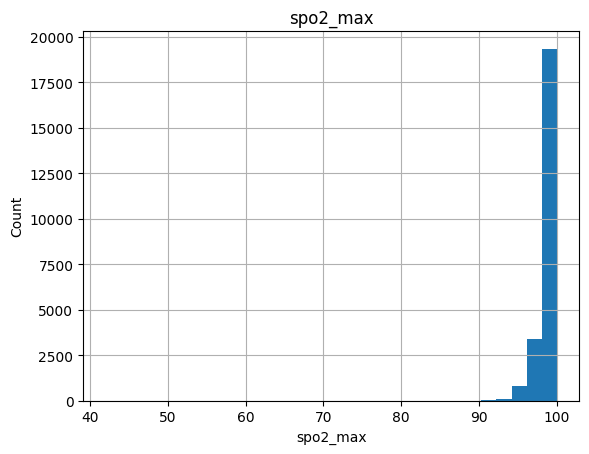

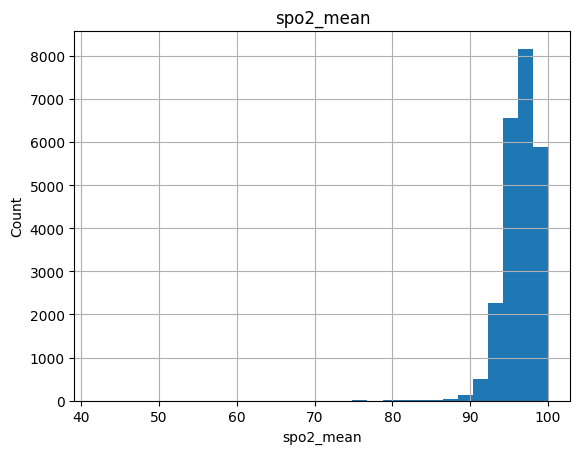

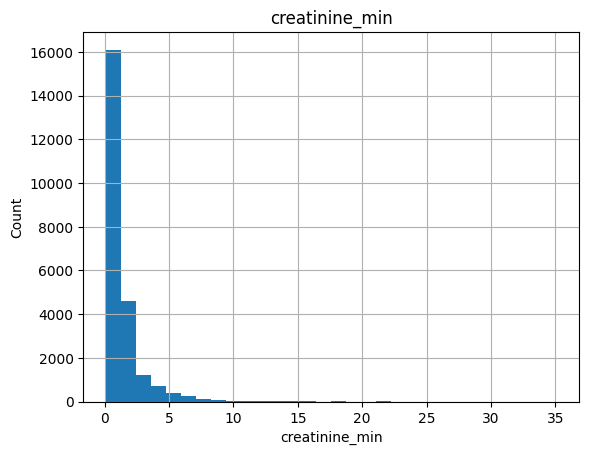

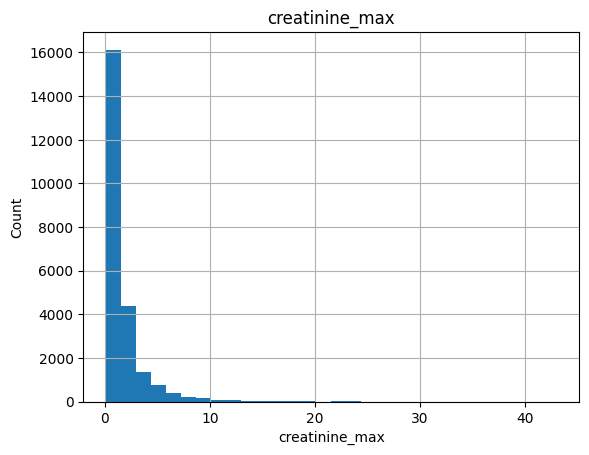

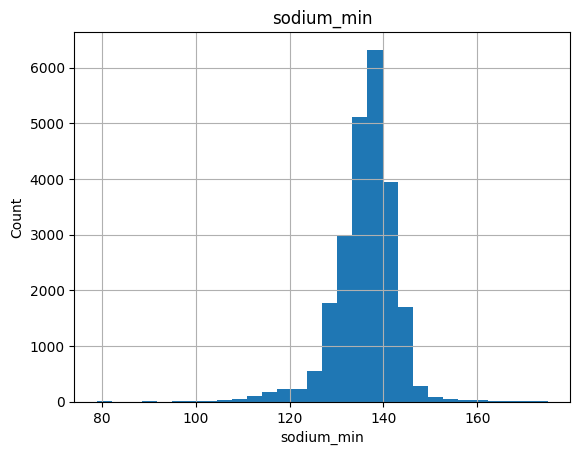

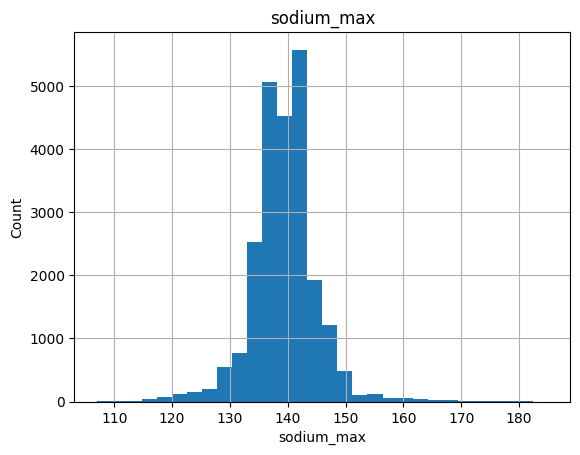

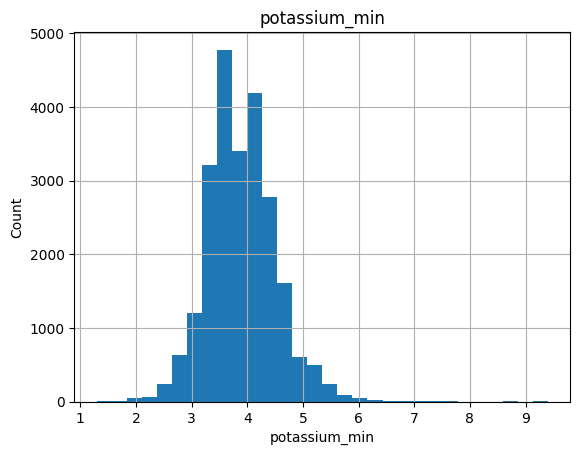

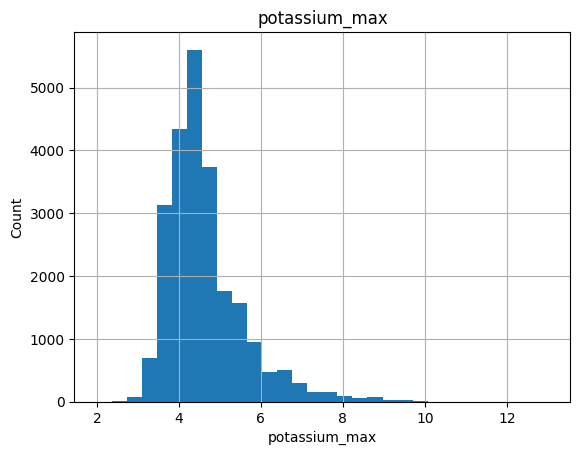

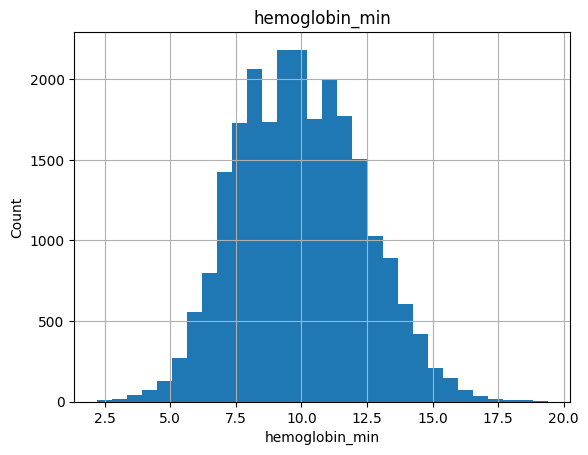

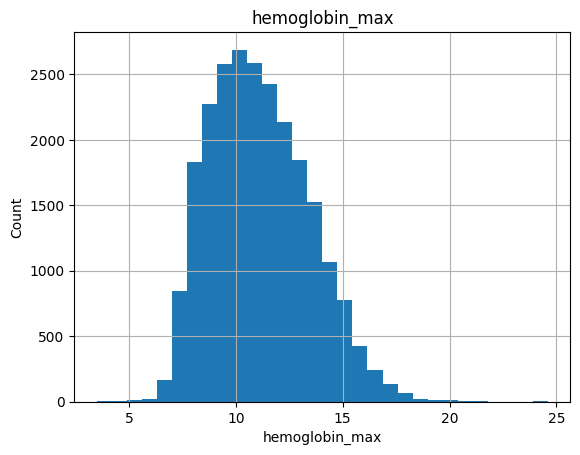

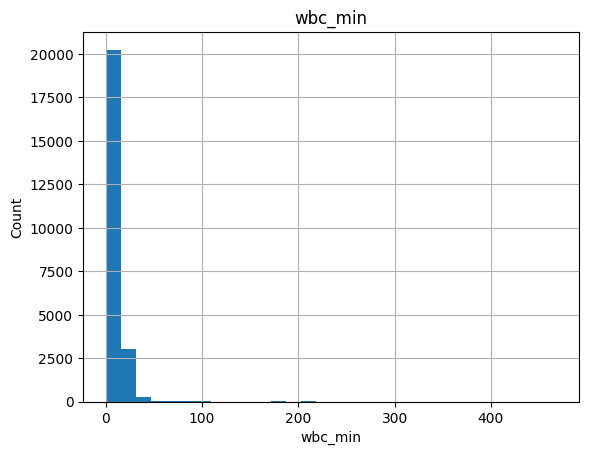

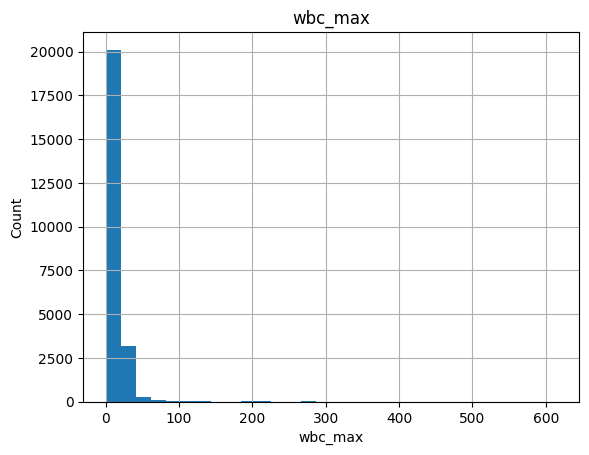

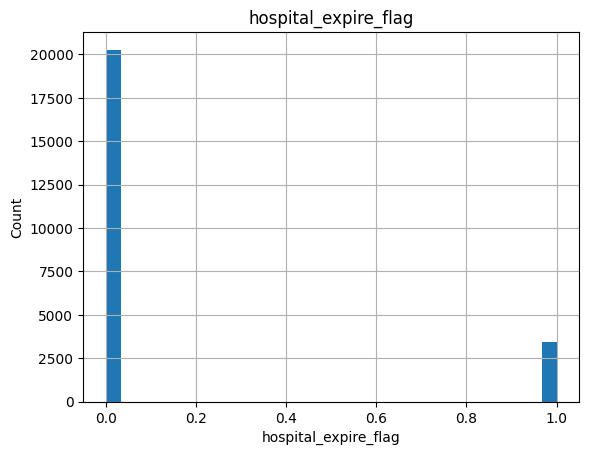

In [6]:
num_cols = df_filtered2.select_dtypes(include=[np.number]).columns.tolist()
for col in num_cols:
    plt.figure()
    df_filtered2[col].dropna().hist(bins=30)
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.show()

## 6. Categorical Distributions

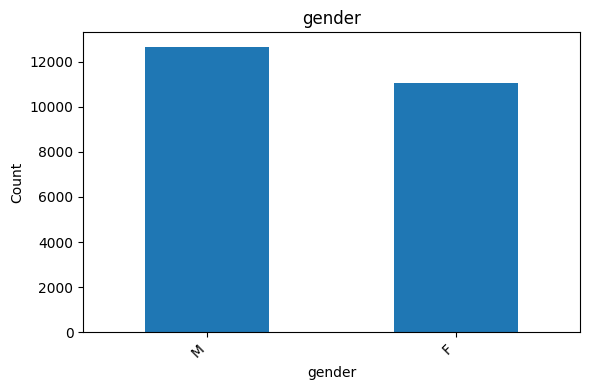

In [7]:
cat_cols = df_filtered2.select_dtypes(exclude=[np.number]).columns.tolist()
for col in cat_cols:
    plt.figure(figsize=(6,4))
    df_filtered2[col].value_counts(dropna=False).head(20).plot(kind='bar')
    plt.title(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

## 7. Notes
- Columns with high missingness may need imputation or removal
- Highly skewed distributions may require transformation before GAN training